In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load data
df = pd.read_csv("../data/processed/cleaned_data.csv")

df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status,Property_Age
0,1,Tamil Nadu,6,Locality_84,0,1,4740,489.76,0.103325,1990,...,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,35
1,2,Maharashtra,33,Locality_490,1,3,2364,195.52,0.082707,2008,...,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,17
2,3,Punjab,25,Locality_167,0,2,3642,183.79,0.050464,1997,...,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move,28
3,4,Rajasthan,21,Locality_393,1,2,2741,300.29,0.109555,1991,...,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move,34
4,5,Rajasthan,19,Locality_466,2,4,4823,182.90,0.037922,2002,...,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,23


In [4]:
# Check columns
print(df.columns)

# Data types
df.info()

# Shape
print("Shape:", df.shape)

# Check calculations
df[["Price_in_Lakhs", "Size_in_SqFt", "Price_per_SqFt"]].head()
df[["Year_Built", "Property_Age"]].head()

# Missing values
df.isnull().sum()

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status', 'Property_Age'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  int64  
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  int64  
 5   BHK             

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
Property_Age                      0
dtype: int64

The dataset is clean with no missing values. 
New features such as Price_per_SqFt and Property_Age are correctly created.
Most features are numerical, making the dataset suitable for machine learning.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,250000.0,125000.500000,72168.927986,1.000000,62500.750000,125000.500000,187500.250000,250000.00000
City,250000.0,20.284840,12.193286,0.000000,10.000000,20.000000,31.000000,41.00000
Property_Type,250000.0,1.003152,0.816574,0.000000,0.000000,1.000000,2.000000,2.00000
BHK,250000.0,2.999396,1.415521,1.000000,2.000000,3.000000,4.000000,5.00000
Size_in_SqFt,250000.0,2749.813216,1300.606954,500.000000,1623.000000,2747.000000,3874.000000,5000.00000
Price_in_Lakhs,250000.0,254.586854,141.349921,10.000000,132.550000,253.870000,376.880000,500.00000
Price_per_SqFt,250000.0,0.130583,0.130719,0.002022,0.048028,0.092447,0.159874,0.99182
Year_Built,250000.0,2006.520012,9.808575,1990.000000,1998.000000,2007.000000,2015.000000,2023.00000
Furnished_Status,250000.0,1.000760,0.816398,0.000000,0.000000,1.000000,2.000000,2.00000
Floor_No,250000.0,14.966800,8.948047,0.000000,7.000000,15.000000,23.000000,30.00000


The dataset shows a wide range of values in price and size, indicating diversity in property listings. 
Some features may contain outliers due to large variations.

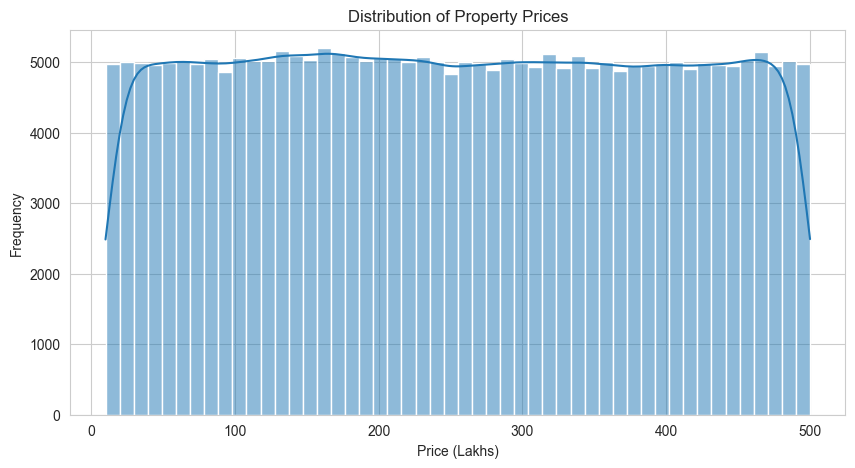

In [6]:
sns.histplot(df["Price_in_Lakhs"], kde=True, bins=50)

plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()

The distribution appears fairly uniform, indicating a synthetic or evenly generated dataset. 
No strong skewness is observed.

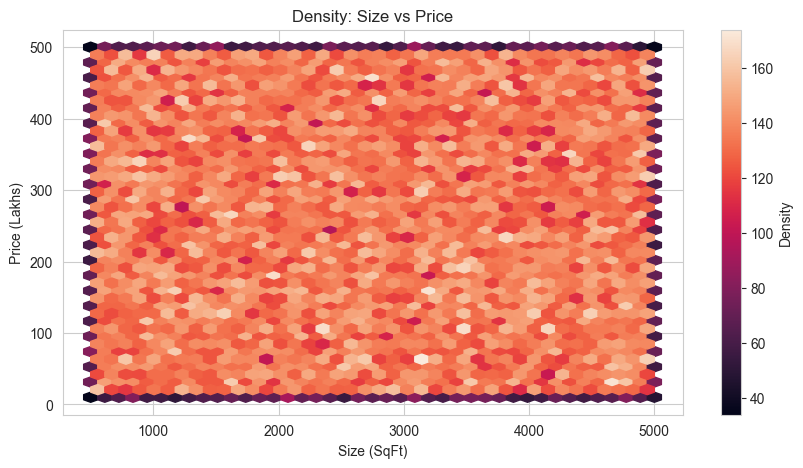

In [7]:
plt.hexbin(
    df["Size_in_SqFt"],
    df["Price_in_Lakhs"],
    gridsize=40
)

plt.xlabel("Size (SqFt)")
plt.ylabel("Price (Lakhs)")
plt.title("Density: Size vs Price")

plt.colorbar(label="Density")
plt.show()

The density plot shows no strong relationship between size and price. 
The distribution is uniform, indicating weak dependency between these variables.

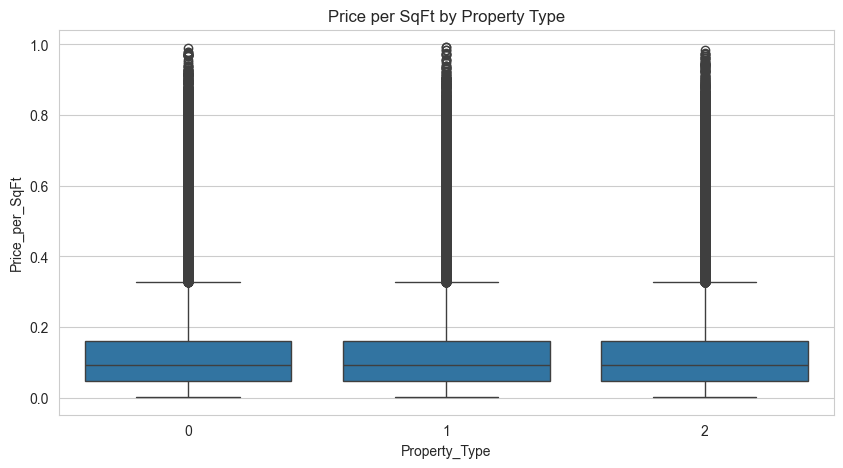

In [8]:
sns.boxplot(
    x="Property_Type",
    y="Price_per_SqFt",
    data=df
)

plt.title("Price per SqFt by Property Type")
plt.show()

Different property types show variation in price per square foot, 
indicating that property type influences pricing.

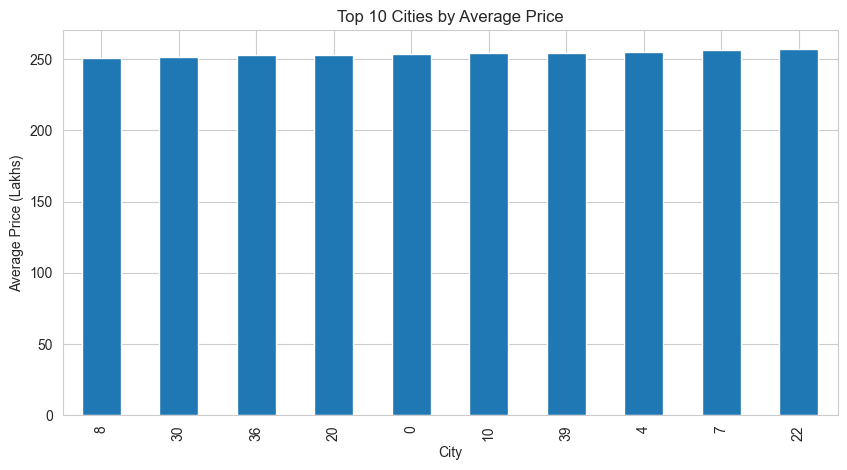

In [9]:
top_cities = df["City"].value_counts().head(10).index

df[df["City"].isin(top_cities)] \
.groupby("City")["Price_in_Lakhs"] \
.mean() \
.sort_values() \
.plot(kind="bar")

plt.title("Top 10 Cities by Average Price")
plt.ylabel("Average Price (Lakhs)")
plt.show()

Some cities have slightly higher average prices, but overall variation is limited, 
suggesting uniform distribution across locations.

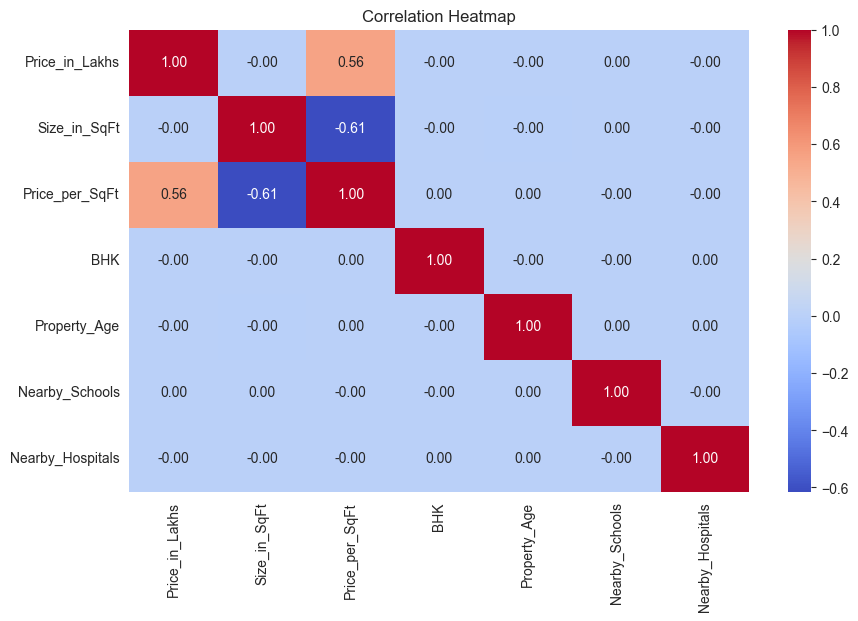

In [10]:
important_cols = [
    "Price_in_Lakhs",
    "Size_in_SqFt",
    "Price_per_SqFt",
    "BHK",
    "Property_Age",
    "Nearby_Schools",
    "Nearby_Hospitals"
]

plt.figure(figsize=(10, 6))

sns.heatmap(
    df[important_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Most features show weak correlation with price. 
This indicates that no single feature strongly influences property pricing. 
Multiple features together may be required for accurate prediction.

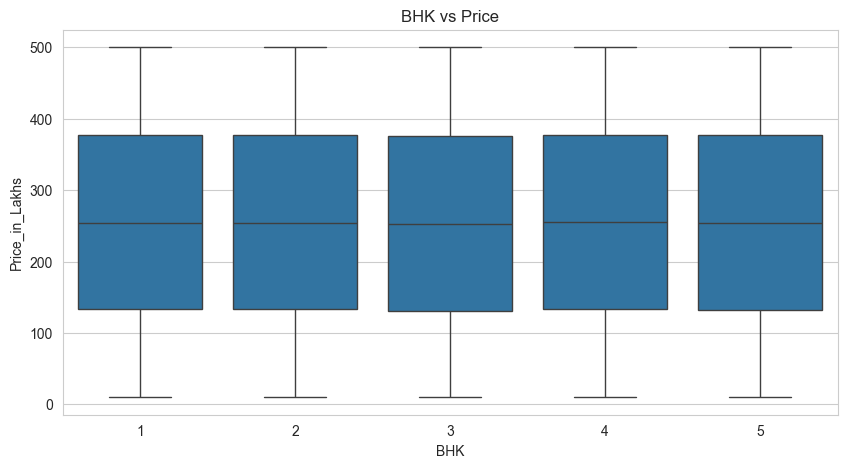

In [11]:
sns.boxplot(x="BHK", y="Price_in_Lakhs", data=df)

plt.title("BHK vs Price")
plt.show()

Higher BHK properties tend to have slightly higher prices, 
but the relationship is not strongly defined.

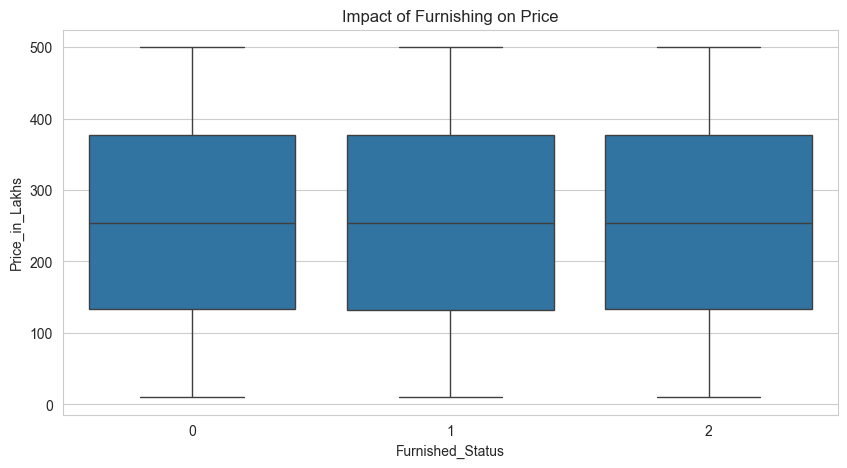

In [12]:
sns.boxplot(
    x="Furnished_Status",
    y="Price_in_Lakhs",
    data=df
)

plt.title("Impact of Furnishing on Price")
plt.show()

Furnishing status shows minimal impact on pricing in this dataset, 
indicating weak dependency.

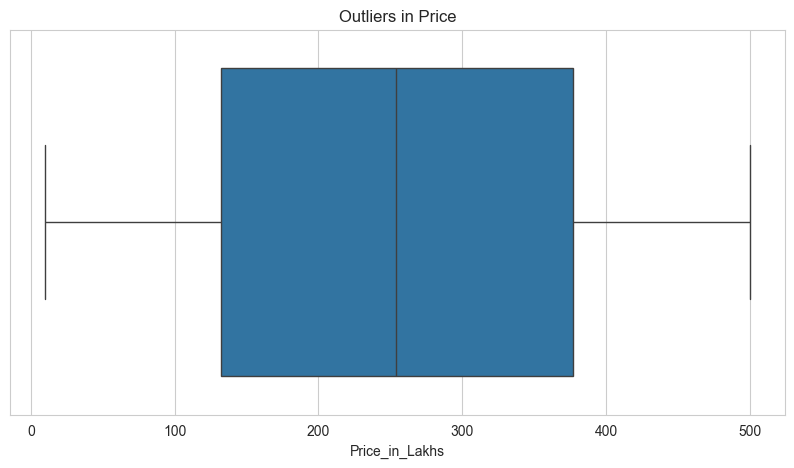

In [13]:
sns.boxplot(x=df["Price_in_Lakhs"])

plt.title("Outliers in Price")
plt.show()

No extreme outliers are observed, suggesting a controlled or synthetic dataset.

Key Findings:

- The dataset appears to be uniformly distributed, suggesting synthetic data.
- No strong correlation exists between size and price.
- Property type and BHK have some influence on pricing.
- Location impact is limited in this dataset.
- Multiple features together are required for prediction rather than relying on a single feature.
- The dataset is clean, structured, and suitable for machine learning.